In [17]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec

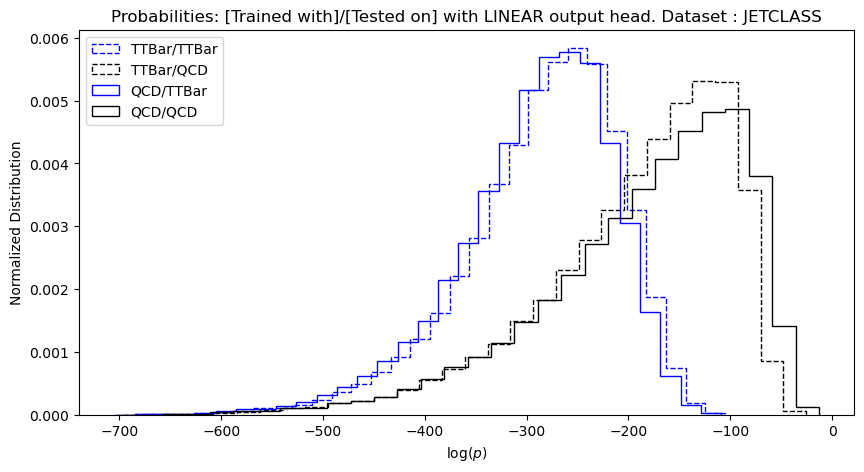

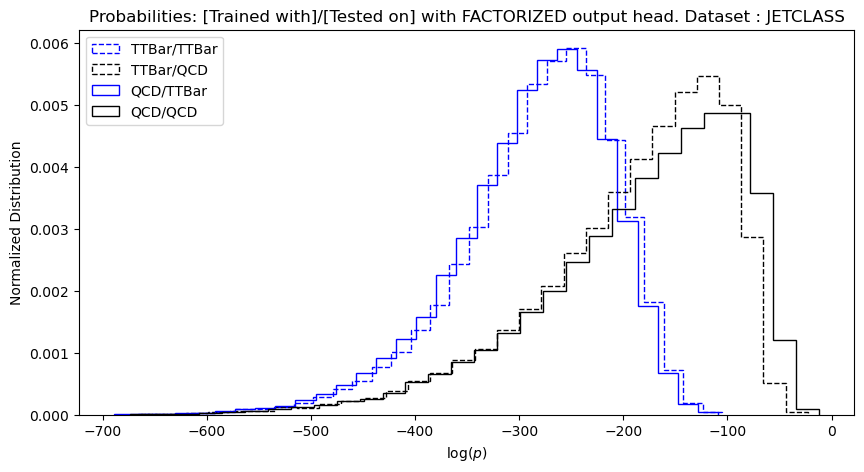

In [18]:
# [trained_on]_[data_from]
DATASET = "JETCLASS"
outputmodes = ["LINEAR", "FACTORIZED"]

classes = ["TTBar", "QCD"]
colors = ["blue", "black"]
lines = ["--", "-"]


for mode in outputmodes:
        
    fig, ax = plt.subplots(figsize=(10, 5))

    bins = 30

    for i in range(len(classes)):
        for j in range(len(classes)):
            # normalized histogram (area = 1), step style
            data = pd.read_csv(f"../output/plot_data_{DATASET.lower()}/probs_best_epoch/{classes[i]}_{mode}_{classes[j]}.csv")

            ax.hist(
                data["probs"],
                bins=bins,                 # adjust for smoothness
                density=True,            # normalization
                histtype="step",
                linewidth=1.0,
                linestyle=lines[i],
                color=colors[j],
                label=f"{classes[i]}/{classes[j]}"
            )


    ax.set_ylabel("Normalized Distribution")
    ax.set_xlabel(r"$\log(p)$")

    ax.set_title(f"Probabilities: [Trained with]/[Tested on] with {mode} output head. Dataset : {DATASET}")

    ax.legend()

    plt.show()